# seaborn
https://seaborn.pydata.org/index.html

- matplotlib 기반의 고수준 시각화 라이브러리
- seaborn은 Matplotlib 위에서 더 간단하고 예쁜 통계 그래프를 그릴 수 있음
- seaborn은 다양한 데이터셋을 쉽게 시각화할 수 있음
    - seaborn 예제 데이터셋 제공: https://github.com/mwaskom/seaborn-data
    - seaborn.load_dataset('dataset명') 으로 다운로드 가능

## ⚙️환경설정

In [9]:
!pip install seaborn

In [22]:
import seaborn as sns
sns.__version__

'0.13.2'

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

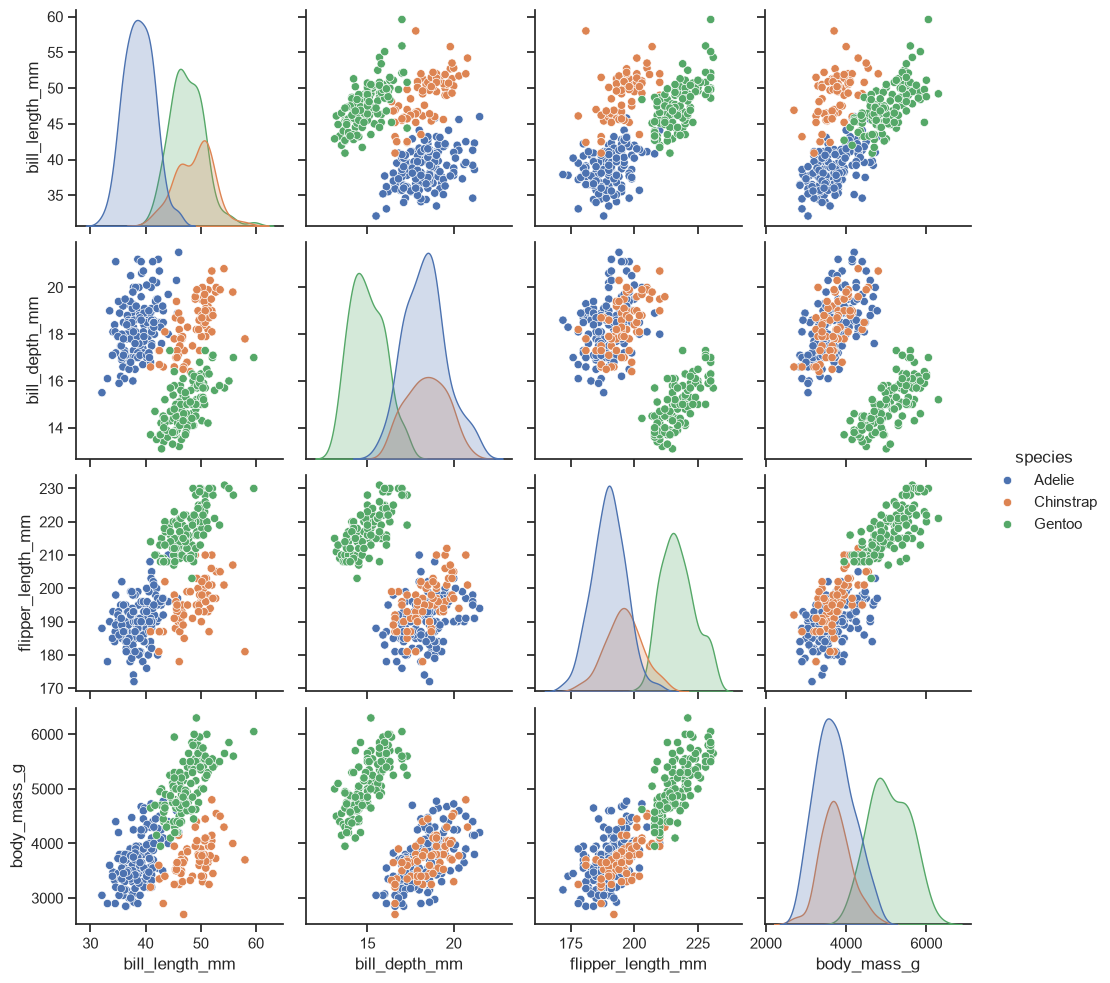

In [13]:
sns.set_theme(style='ticks') # seaborn 생성 그래프의 테마 지정

# seaborn에서 제공하는 예시 데이터셋 목록 조회
# print(sns.get_dataset_names())

# seaborn 예제 데이터셋 로드(DataFrame 타입)
df = sns.load_dataset("penguins")
# df.info()
df.head()   # 상위 5개 조회

# sns.pairplot() : 여러 변수 조합의 산점도와 분포를 한 번에 표시
# hue : 색상 그룹 지정
# hue="specie" : species 값을 그룹으로 하여 색을 나눔
sns.pairplot(df, hue="species")
plt.show()

## Histogram

히스토그램은 **연속된 숫자 데이터를 일정한 구간으로 나누고, 각 구간에 데이터가 몇 개씩 들어 있는지 막대로 보여주는 그래프**이다.
- 연속형 데이터: 값이 끊어지지 않고 이어지는 숫자 데이터
- 도수 분포: 데이터를 일정한 구간으로 나누고, 각 구간에 데이터가 몇 개씩 들어 있는지 센 것

```
예를 들어 학생 점수 데이터가 있을 때,
`0~10점`, `10~20점`, `20~30점`처럼 점수 구간을 나눈 뒤
각 구간에 학생이 몇 명 있는지 막대 높이로 표현한다.
```

### 히스토그램으로 확인할 수 있는 것

- 데이터가 어느 구간에 많이 몰려 있는지
- 값이 전체적으로 낮은 편인지 높은 편인지
- 데이터가 한쪽으로 치우쳐 있는지
- 특이하게 멀리 떨어진 값이 있는지

### displot()과 histplot()

1. `displot()`
   - seaborn의 Figure-level 함수
   - 그래프 전체 Figure를 새로 만들어 그림
   - 크기는 주로 `height`, `aspect`로 조절함

2. `histplot()`
   - seaborn의 Axes-level 함수
   - 현재 Figure나 Axes 위에 히스토그램을 그림
   - `plt.figure(figsize=(가로, 세로))`처럼 Matplotlib 설정과 함께 사용하기 좋음

### 주요 매개변수

- `bins`: 데이터를 몇 개의 구간으로 나눌지 지정
- `kde=True`: 부드러운 분포 곡선을 함께 표시
- `rug=True`: 실제 데이터 위치를 작은 선으로 표시


In [14]:
titanic_df = pd.read_csv('data/titanic.csv')
# titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


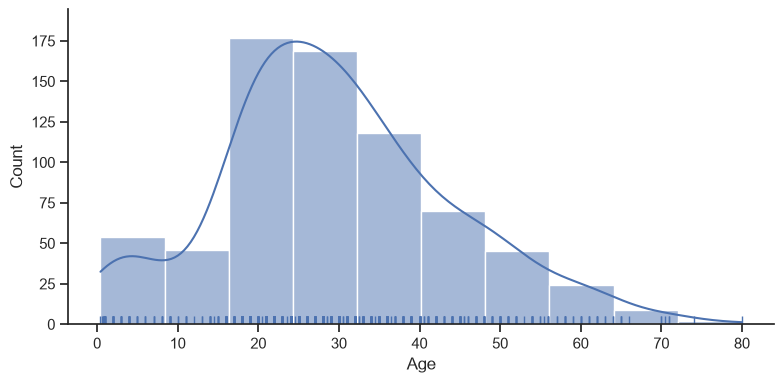

In [18]:
# 승객 나이 분포를 displot 히스토그램을 이용해서 확인

sns.displot(
    titanic_df['Age'],
    bins=10,     # 히스토그램 막대 개수(== 구간 수)
    height=4,
    aspect=2,    # 가로/세로 비율
    rug=True,    # 데이터의 실제 위치
    kde=True,    # 데이터 밀도 곡선

)

plt.show()

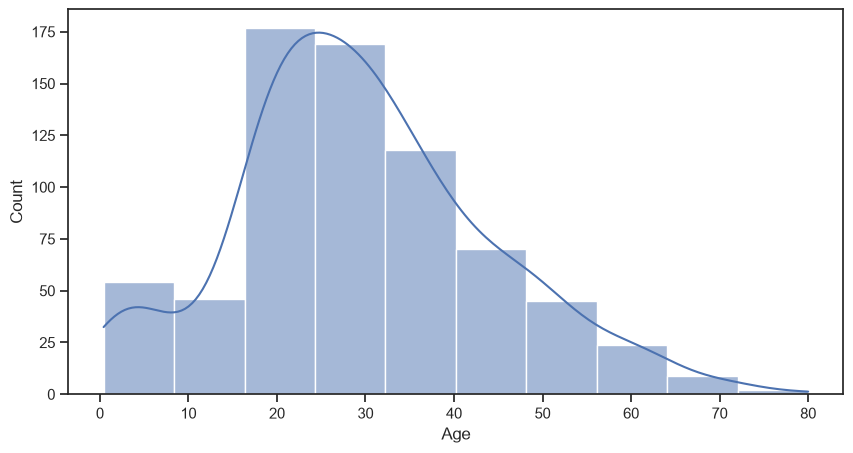

In [20]:
# histplot으로 승객 나이 분포도 만들기

plt.figure(figsize=(10, 5)) # 피겨 생성

sns.histplot(titanic_df['Age'], bins=10, kde=True)
plt.show()

## Bar Plot

막대그래프는 **범주별로 데이터의 개수나 평균 같은 수치값을 막대 길이로 비교하는 그래프**이다.
- 범주형 데이터: 정해진 그룹이나 이름으로 나뉘는 데이터
- 수치값: 개수, 평균, 합계처럼 계산할 수 있는 값

```
예를 들어 Titanic 데이터에서 객실 등급이 1등석, 2등석, 3등석으로 나뉘어 있을 때,
각 등급에 승객이 몇 명 있는지 또는 등급별 평균 나이가 얼마인지 막대 길이로 비교한다.
```

### 막대그래프로 확인할 수 있는 것

- 어떤 범주에 데이터가 많이 몰려 있는지
- 범주별 평균이나 합계가 어떻게 다른지
- 여러 그룹을 색으로 나누었을 때 차이가 있는지
- 범주 간 크기 차이와 순위가 어떤지

### countplot()과 barplot()

1. `countplot()`
   - 범주별 데이터 개수를 세어 막대로 표시함
   - 별도의 y값 없이 x축 범주만으로 개수 계산 가능

2. `barplot()`
   - 범주별 수치형 데이터의 대표값을 막대로 표시함
   - 기본 대표값은 평균
   - `estimator`로 평균, 합계 등 계산 방식 변경 가능

### 주요 매개변수

- `x`: x축에 놓을 범주형 컬럼
- `y`: y축에 놓을 수치형 컬럼
- `hue`: 색으로 한 번 더 나눌 그룹 컬럼
- `palette`: 그래프 색상 조합
- `estimator`: 막대 높이를 계산하는 방식
- `errorbar`: 오차막대 표시 방식


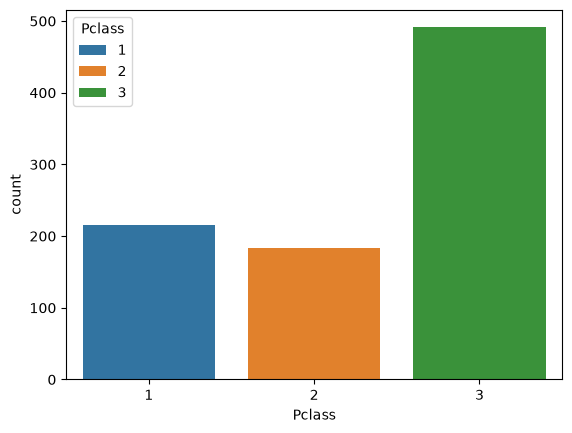

In [24]:
# 객실 등급별 승객 수를 countplot으로 확인
sns.countplot(
    x='Pclass',
    data=titanic_df,
    palette='tab10',    # matplotlib에서 제공하는 색상 팔레트
    hue='Pclass'
)
plt.show()

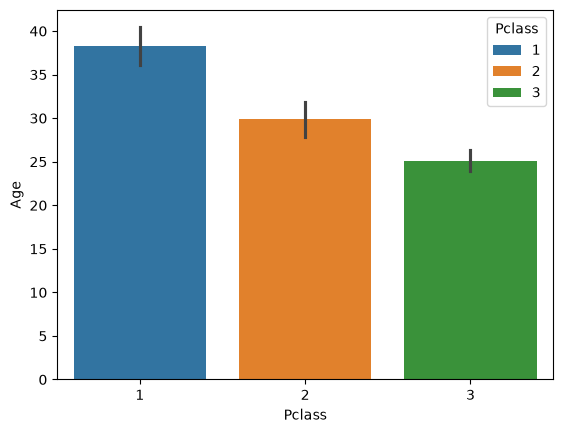

In [27]:
# 객실 등급별 평균 나이를 barplot으로 확인
sns.barplot(
    data=titanic_df,
    x='Pclass',
    y='Age',
    palette='tab10',
    hue='Pclass',
    estimator=np.mean
)
plt.show()

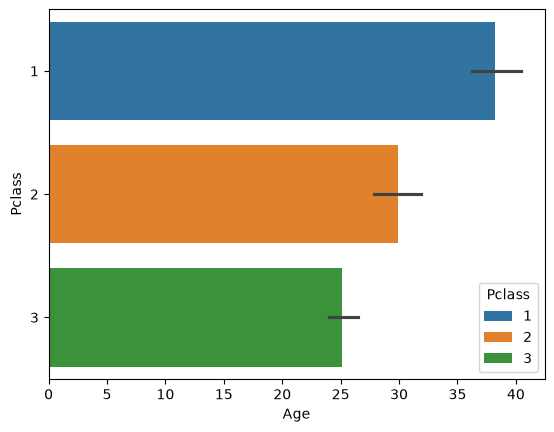

In [28]:
# 객실 등급별 평균 나이를 수평 barplot으로 확인
sns.barplot(
    data=titanic_df,
    x='Age',
    y='Pclass',
    palette='tab10',
    hue='Pclass',
    estimator=np.mean,
    orient='h'  # 막대 방향 h(수평)
)
plt.show()

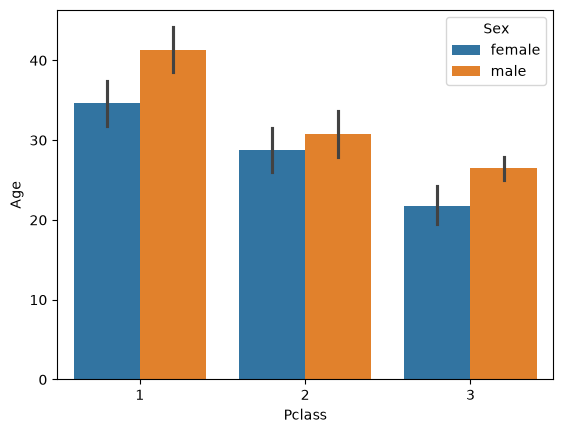

In [29]:
# 객실 등급과 성별에 따른 평균 나이를 barplot으로 확인
sns.barplot(
    data=titanic_df,
    x='Pclass', # 객실 등급으로 1차 그뤂
    y='Age',
    palette='tab10',
    hue='Sex',  # 성별로 2차 그룹
    estimator=np.mean
)
plt.show()

## Box Plot

박스플롯은 **데이터의 중앙값, 사분위수, 이상값 후보를 상자와 선으로 요약해서 보여주는 그래프**이다.
- 중앙값: 데이터를 순서대로 정렬했을 때 가운데 위치한 값
- 사분위수: 데이터를 4등분하는 기준값
- 이상값 후보: 다른 값들과 멀리 떨어져 있는 값

```
예를 들어 객실 등급별 승객 나이 분포를 볼 때,
각 등급의 나이가 어디에 많이 모여 있는지와 특이하게 나이가 많은 값이 있는지 한 번에 확인한다.
```

### 박스플롯으로 확인할 수 있는 것

- 데이터의 가운데 값이 어디인지
- 데이터가 얼마나 넓게 퍼져 있는지
- 범주별 분포가 서로 다른지
- 이상값 후보가 있는지 -> 그래프에서 o 로 표시됨

### boxplot()
- 수치형 데이터의 분포를 상자로 요약함
- x축에 범주를 지정하면 범주별 분포 비교 가능
- y축에 수치형 컬럼을 지정해 분포 확인

### 주요 매개변수

- `data`: 사용할 DataFrame
- `x`: 그룹을 나눌 범주형 컬럼
- `y`: 분포를 확인할 수치형 컬럼
- `hue`: 색으로 한 번 더 나눌 그룹 컬럼


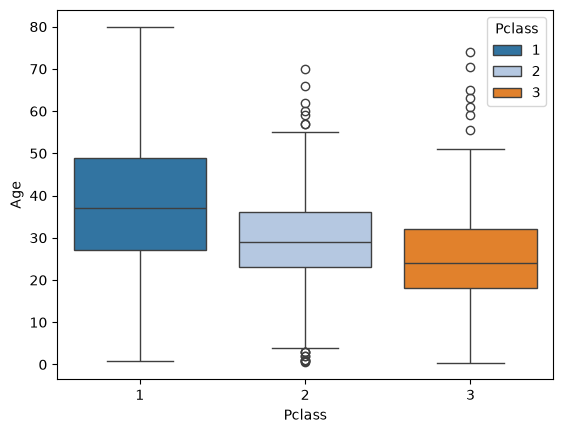

In [35]:
# 객실 등급별 나이 분포를 boxplot으로 비교
sns.boxplot(
    data=titanic_df,
    x='Pclass',
    y='Age',
    hue='Pclass',
    palette='tab20',
)
plt.show()

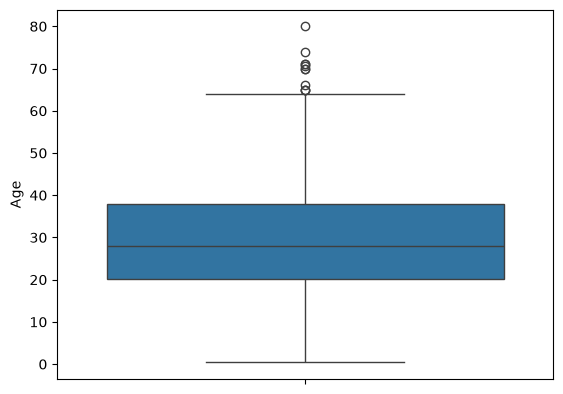

In [37]:
# 전체 승객 나이 분포를 단일 boxplot으로 확인
# -> x=None, hue=None
sns.boxplot(data=titanic_df,
            y='Age'
            )
plt.show()

## Violin Plot

바이올린 플롯은 **박스플롯에 데이터가 어디에 많이 몰려 있는지 보여주는 밀도 모양을 더한 그래프**이다.
- 밀도: 값이 어느 구간에 많이 모여 있는지 부드러운 곡선 형태로 나타낸 것
- 폭이 넓은 부분: 데이터가 많이 모여 있는 구간
- 폭이 좁은 부분: 데이터가 적은 구간

```
예를 들어 객실 등급별 나이 분포를 비교할 때,
단순히 중앙값만 보는 것이 아니라 어느 나이대에 승객이 많이 몰려 있는지도 함께 확인한다.
```

### 바이올린 플롯으로 확인할 수 있는 것

- 데이터가 어느 값 주변에 많이 몰려 있는지
- 범주별 분포 모양이 비슷한지 다른지
- 한쪽으로 치우친 분포인지
- 여러 봉우리를 가진 분포인지

### violinplot()
- 수치형 데이터의 분포와 밀도 모양을 함께 표시함
- 범주별 분포 비교에 사용하기 좋음
- 박스플롯보다 분포 모양을 더 자세히 볼 수 있음

### 주요 매개변수

- `data`: 사용할 DataFrame
- `x`: 그룹을 나눌 범주형 컬럼
- `y`: 분포를 확인할 수치형 컬럼
- `hue`: 색으로 한 번 더 나눌 그룹 컬럼
- `palette`: 그래프 색상 조합


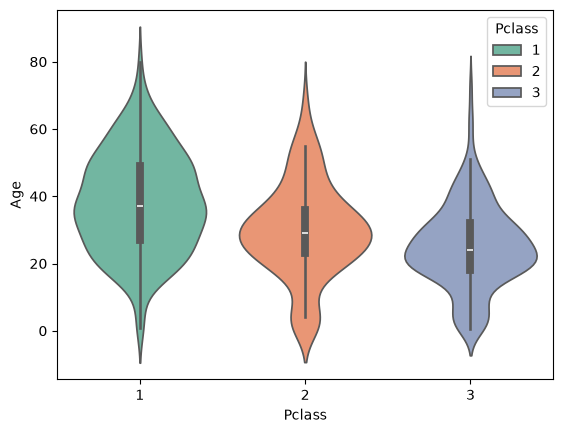

In [40]:
# 객실 등급별 나이 밀도 분포를 violinplot으로 확인
sns.violinplot(
    data=titanic_df,
    x='Pclass',
    y='Age',
    hue='Pclass',
    palette='Set2'
)
plt.show()

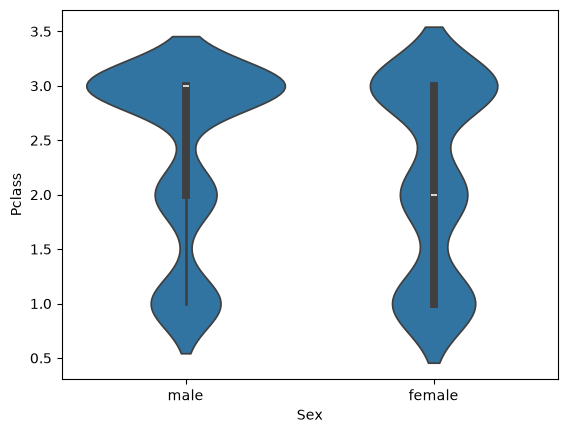

In [44]:
# 성별(x)과 객실 등급(y) 관계를 violinplot으로 확인
sns.violinplot(
    data=titanic_df,
    x='Sex',
    y='Pclass'
)
plt.show()

## Scatter Plot

산점도는 **두 개의 숫자형 변수를 x축과 y축에 놓고, 각 데이터를 점으로 표시하는 그래프**이다.
- x축 변수: 가로 방향으로 비교할 숫자 데이터
- y축 변수: 세로 방향으로 비교할 숫자 데이터
- 점 하나: 데이터 한 행 또는 관측치 하나

```
예를 들어 Titanic 데이터에서 나이를 x축, 요금을 y축에 놓으면,
승객 한 명이 점 하나로 표시되고 나이와 요금 사이의 관계를 볼 수 있다.
```

### 산점도로 확인할 수 있는 것

- 두 숫자형 변수 사이에 관계가 있는지
- 값이 증가할수록 다른 값도 증가하거나 감소하는지
- 점들이 몇 개의 그룹처럼 나뉘는지
- 다른 점들과 멀리 떨어진 이상값 후보가 있는지

### scatterplot()
- 두 수치형 변수의 관계를 점으로 표시함
- `hue`, `style`을 사용하면 색과 마커 모양으로 그룹 구분 가능

### 주요 매개변수

- `data`: 사용할 DataFrame
- `x`: x축에 놓을 수치형 컬럼
- `y`: y축에 놓을 수치형 컬럼
- `hue`: 색으로 나눌 그룹 컬럼
- `style`: 마커 모양으로 나눌 그룹 컬럼
- `palette`: 그래프 색상 조합


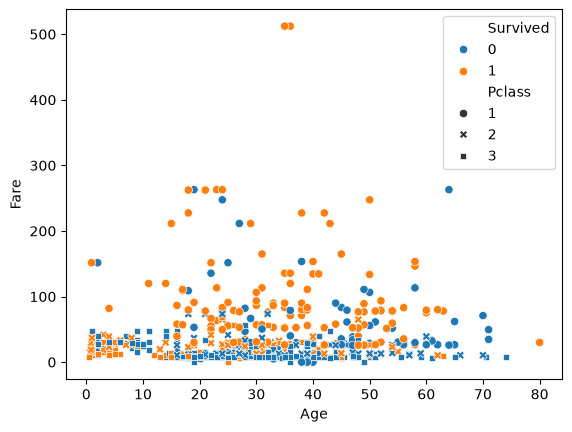

In [51]:
# 나이와 요금 관계를 생존 여부와 객실 등급으로 구분한 산점도
sns.scatterplot(
    data=titanic_df,
    x='Age',
    y='Fare',
    hue='Survived', # 그룹 (색상을 다르게 표현)
    style='Pclass' # 그룹 (모양을 다르게 표현)
)
plt.show()

## 상관 Heatmap

상관 히트맵은 **여러 숫자형 컬럼 사이의 상관계수를 색으로 보여주는 그래프**이다.
- 상관계수: 두 변수가 함께 움직이는 방향과 강도를 나타내는 값
- 양수: 한 변수가 커질 때 다른 변수도 커지는 경향
- 음수: 한 변수가 커질 때 다른 변수는 작아지는 경향
- 0 근처: 뚜렷한 선형 관계가 약함

```
예를 들어 Titanic 데이터에서 Fare와 Survived의 상관계수를 보면,
요금이 생존 여부와 어느 정도 함께 움직이는지 숫자와 색으로 확인할 수 있다.
```

### 상관 히트맵으로 확인할 수 있는 것

- 어떤 변수들이 서로 강하게 관련되어 있는지
- 양의 관계인지 음의 관계인지
- 분석이나 모델링에서 함께 볼 만한 변수가 무엇인지
- 너무 비슷하게 움직이는 변수들이 있는지

### heatmap()

1. `corr()`
   - 숫자형 컬럼끼리 상관계수를 계산함
   - ID처럼 의미 없는 숫자 컬럼은 제외하는 것이 좋음

2. `heatmap()`
   - 상관계수 표를 색으로 시각화함
   - 색이 진할수록 관계가 강하게 보임

### 주요 매개변수

- `annot=True`: 각 칸에 실제 숫자를 표시
- `fmt='.2f'`: 숫자를 소수점 둘째 자리까지 표시
- `cmap`: 사용할 색상표
- `vmin`, `vmax`: 색상 범위의 최소값과 최대값


### 상관계수 (Correlation Coefficient)란?

> 두 변수 간에 **서로 얼마나 함께 움직이는지**를 나타내는 수치.

- **양의 상관**: 같이 커지고 같이 작아짐 → 상관계수 > 0
- **음의 상관**: 한쪽이 커질 때 다른쪽이 작아짐 → 상관계수 < 0
- **상관 없음**: 서로 관계가 없음 → 상관계수 ≈ 0

**상관계수 값 해석**

| 상관계수 값 | 의미 |
|:---|:---|
| +1 | 완벽한 양의 상관 |
| 0 | 상관 없음 |
| -1 | 완벽한 음의 상관 |


**피어슨 상관계수 공식**

피어슨 상관계수 $ r $ 공식:

$$
r = \frac{공분산(X, Y)}{표준편차(X) \times 표준편차(Y)}
$$

- **공분산**: 두 변수가 함께 변하는 정도. 값이 들쑥날쑥이라 상관계수로 표현하기 어려움
- **표준편차**: 각각 변수가 얼마나 퍼져 있는지


#### 공분산이란?
> 두 변수가 얼마나 함께 변하는지를 측정하는 값.

$$
공분산(X, Y) = \frac{\sum (X_i - 평균(X))(Y_i - 평균(Y))}{n}
$$

- 양수 → 같은 방향으로 움직임
- 음수 → 반대 방향으로 움직임
- 0 → 관련 없음

**피어슨 상관계수 계산 흐름**

1. **평균** 계산 (X와 Y 각각)
2. **편차** 계산 (각 데이터 - 평균)
3. **편차끼리 곱해서 평균** → 공분산 계산
4. **각 변수의 표준편차** 계산
5. **공분산 ÷ (표준편차 X × 표준편차 Y)** → 피어슨 상관계수 완성

In [57]:
# 타이타닉 데이터 중 수치형 데이터(int, float 등)
# 커럼간의 상관계수를 계산
corr_mat = titanic_df.corr(numeric_only=True)
corr_mat


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


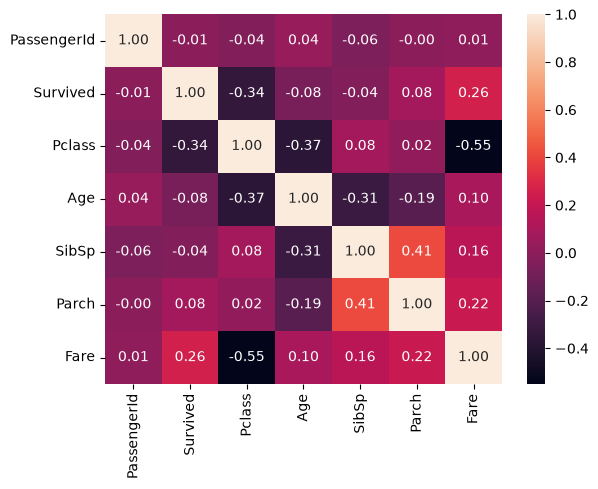

In [59]:
# 위에 계산된 상관계수를 이용해서 heatmap 만들기
# annot=True : 각 칸에 실제 숫자 표기
# fmt= '.2f' : 표기되는 숫자를 소수점 아래 둘째자리까지 표현
sns.heatmap(
    data=corr_mat,
    annot=True,
    fmt='.2f'
)
plt.show()

| 관계 | 값 | 해석 |
|---|---:|---|
| `Pclass` ↔ `Fare` | `-0.55` | 객실 등급 숫자가 커질수록 요금은 낮아지는 경향. 타이타닉에서 `1등급=1`, `3등급=3`이라서 음수로 나옴 |
| `Survived` ↔ `Pclass` | `-0.34` | 객실 등급 숫자가 커질수록 생존 여부는 낮아지는 경향. 즉 1등급 승객 생존률이 상대적으로 높았을 가능성 |
| `Survived` ↔ `Fare` | `0.26` | 요금이 높을수록 생존과 약간 양의 관계가 있음 |
| `SibSp` ↔ `Parch` | `0.41` | 형제/배우자 수와 부모/자녀 수가 어느 정도 같이 증가하는 경향 |
| `Age` ↔ `Pclass` | `-0.37` | 객실 등급 숫자가 낮을수록, 즉 높은 등급일수록 나이가 많은 승객이 상대적으로 있었을 가능성 |

## Pairplot

페어플롯은 **여러 숫자형 변수들의 관계를 한 번에 비교해서 보여주는 그래프 묶음**이다.
- 대각선 영역: 각 변수 하나의 분포
- 대각선 밖 영역: 두 변수 사이의 산점도
- 여러 변수 관계를 빠르게 훑어볼 때 사용함

```
예를 들어 Age, Fare, Pclass, Survived를 함께 넣으면,
각 변수의 분포와 변수끼리의 관계를 한 화면에서 비교할 수 있다.
```

### 페어플롯으로 확인할 수 있는 것

- 변수별 분포가 어떤 모양인지
- 두 변수 사이에 관계가 보이는지
- 그룹별로 점들이 나뉘는지
- 분석할 변수 조합을 빠르게 찾을 수 있는지

### pairplot()
- 여러 변수 조합의 산점도와 각 변수의 분포를 한 번에 표시함
- 탐색적 데이터 분석에서 변수 관계를 빠르게 확인할 때 사용함

### 주요 매개변수

- `data`: 사용할 DataFrame
- `hue`: 색으로 나눌 그룹 컬럼
- `vars`: 비교할 변수 목록
- `diag_kind`: 대각선에 표시할 분포 그래프 종류


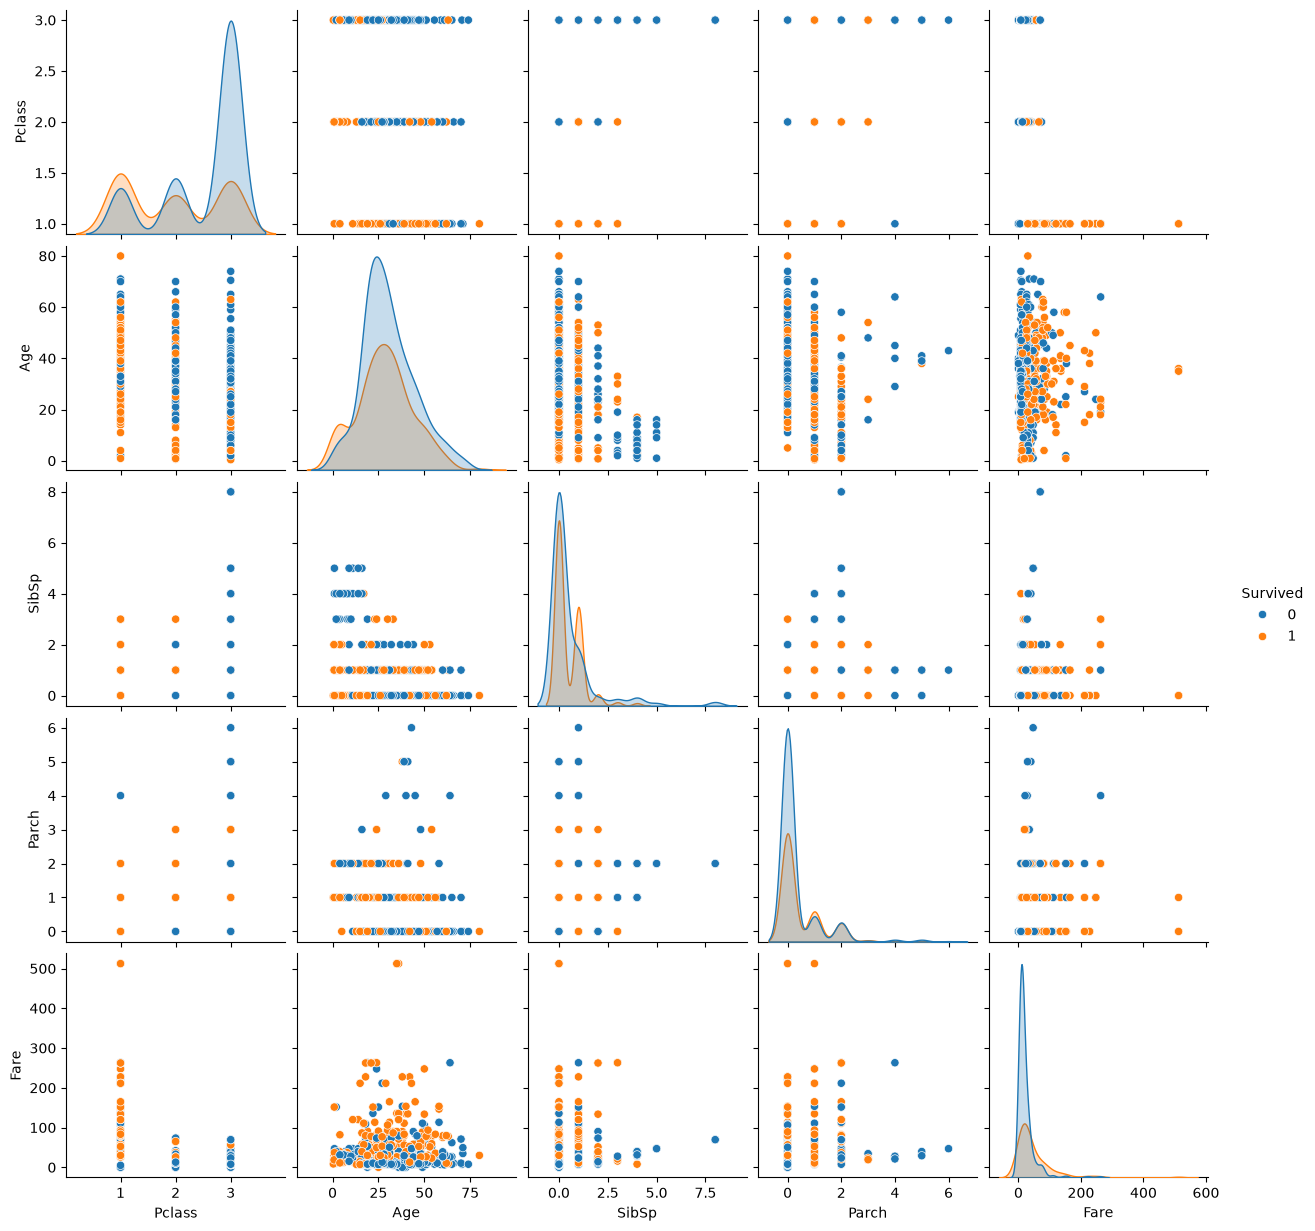

In [60]:
# 타이타닉 주요 변수 관계를 pairplot으로 한 눈에 확인하기
sns.pairplot(
    data=titanic_df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']],
    hue='Survived',     # 색상으로 그룹 구분
)

plt.show()

# Pclass    3등급 승객이 많고, 파란색이 많이 보임. 3등급 승객의 사망 비율이 상대적으로 높았을 가능성
# Pclass ↔ Fare    1등급일수록 요금이 높고, 3등급일수록 요금이 낮음
# Fare    낮은 요금 구간에 승객이 많이 몰려 있음. 높은 요금 구간에는 주황색 생존자도 꽤 보임
# Age    20~40대 승객이 많음. 나이만으로 생존/사망이 명확하게 나뉘지는 않음
# SibSp, Parch    대부분 0 근처에 몰려 있음. 즉 혼자 탑승한 사람이 많음
# Age ↔ Fare    나이와 요금 사이에는 뚜렷한 직선 관계가 잘 보이지 않음
# Pclass ↔ Survived 색상    1등급 쪽에 주황색이 상대적으로 더 보이고, 3등급 쪽에 파란색이 많이 보임

## Regplot

회귀 플롯은 **산점도 위에 두 변수의 전체적인 관계를 나타내는 회귀선을 함께 그린 그래프**이다.
- 산점도: 실제 데이터가 찍힌 점
- 회귀선: 데이터의 전체적인 증가 또는 감소 경향을 나타내는 선
- 기본적으로 선형 회귀선을 그림

```
예를 들어 음식점 결제금액(total_bill)과 팁(tip)을 비교하면,
결제금액이 커질수록 팁도 증가하는 경향이 있는지 회귀선으로 확인할 수 있다.
```

### 회귀 플롯으로 확인할 수 있는 것

- 두 수치형 변수 사이의 증가 또는 감소 경향
- 점들이 회귀선 주변에 얼마나 모여 있는지
- 선형 관계가 강한지 약한지
- 이상값이 회귀선에서 크게 벗어나는지

### regplot()
- 산점도와 회귀선을 함께 표시함
- 두 수치형 변수의 관계 방향을 설명하기 좋음

### 주요 매개변수

- `data`: 사용할 DataFrame
- `x`: x축에 놓을 수치형 컬럼
- `y`: y축에 놓을 수치형 컬럼
- `ci`: 회귀선 주변 신뢰구간 표시 범위
- `scatter_kws`: 점 스타일 설정
- `line_kws`: 회귀선 스타일 설정


In [64]:
tips_df = sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


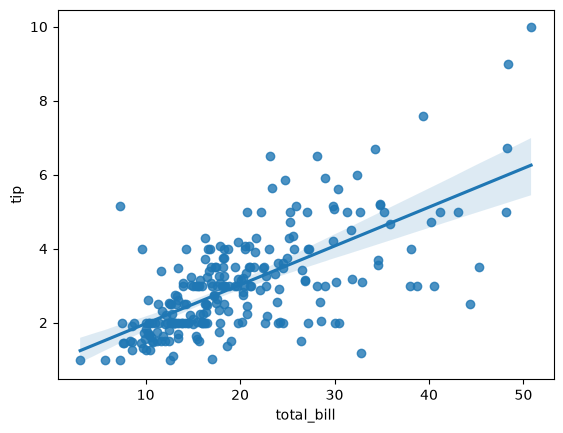

In [65]:
# 결제 금액과 tip의 관계를 회귀선이 포함된 regplot으로 확인
sns.regplot(
    data=tips_df,
    x='total_bill',
    y='tip',
)
plt.show()

In [70]:
# 연료 1갤런으로 몇 마일을 갈 수 있는가
mpg_df = sns.load_dataset('mpg')    # mile per gallon
mpg_df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


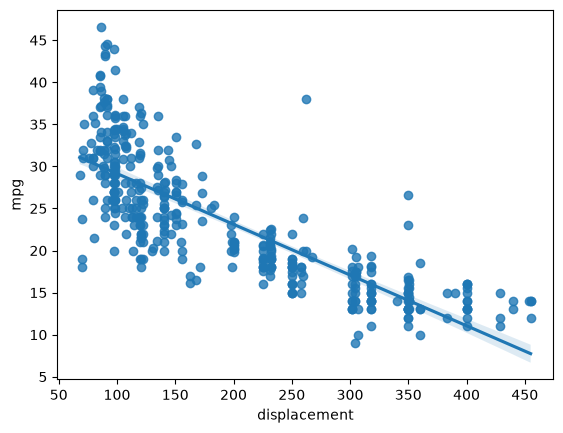

In [71]:
# 배기량과 연비의 상관관계를 regplot으로 확인
sns.regplot(
    data=mpg_df,
    x='displacement',
    y='mpg'
)
plt.show()

## FacetGrid

FacetGrid는 **범주별로 작은 그래프 판을 나누어 같은 그래프를 여러 조건에서 비교하는 기능**이다.
- Facet: 조건별로 나뉜 작은 그래프 하나
- row: 행 방향으로 나눌 기준
- col: 열 방향으로 나눌 기준

```
예를 들어 tips 데이터에서 시간대(time)와 흡연 여부(smoker)로 화면을 나누면,
각 조건별로 결제금액과 팁의 관계를 따로 비교할 수 있다.
```

### FacetGrid로 확인할 수 있는 것

- 조건별 데이터 패턴이 서로 다른지
- 같은 x, y 관계가 그룹마다 어떻게 달라지는지
- 여러 범주를 한 화면에서 나누어 비교할 수 있는지
- 복잡한 그룹 비교를 작은 그래프들로 정리할 수 있는지

### FacetGrid와 map()

1. `FacetGrid()`
   - 데이터를 행과 열 기준으로 나누어 그래프 판을 만듦
   - `row`, `col`에 범주형 컬럼을 지정함

2. `map()`
   - 각 그래프 판에 실제 그래프 함수를 적용함
   - 예: 각 판에 `scatterplot()`을 그림

### 주요 매개변수

- `data`: 사용할 DataFrame
- `row`: 행 방향으로 나눌 기준 컬럼
- `col`: 열 방향으로 나눌 기준 컬럼
- `margin_titles=True`: 행/열 제목을 가장자리에 표시
- `map()`: 각 Facet에 적용할 그래프 함수와 컬럼 지정


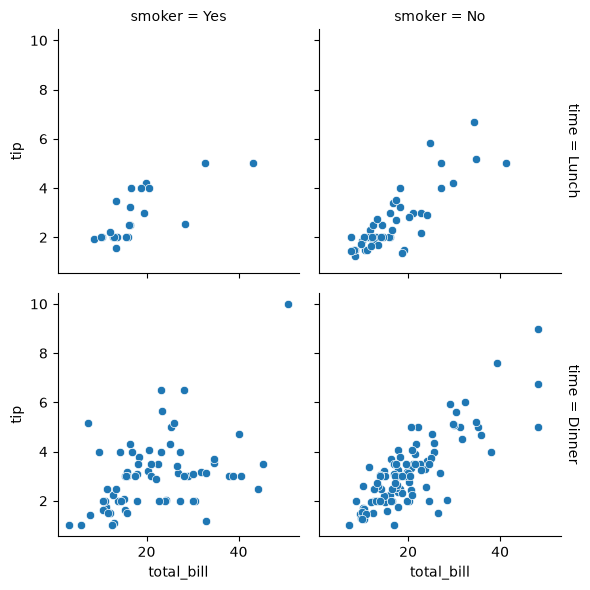

In [74]:
# tips 데이터를 시간대와 흡연 여부로 나누어 산점도 표시
facet_grid = sns.FacetGrid(
    data=tips_df,
    row='time',
    col='smoker',
    margin_titles=True, # 행/열의 제목을 가장자리에 표시
)   # 객체 생성

# 생성된 FacetGrid 객체를 이용해서 출력
# sns.scatterplot : 산점도표로 출력
# 'total_bill', 'tip': 산점도표의 x축과 y축
facet_grid.map(sns.scatterplot, 'total_bill', 'tip')
plt.show()

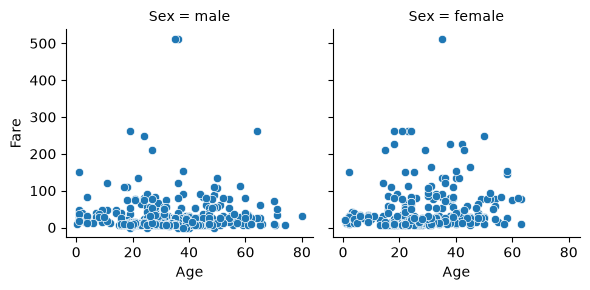

In [79]:
# 타이타닉 데이터를 성별로 나누는 facet_grid 생성
facet_grid = sns.FacetGrid(
    data=titanic_df,
    col='Sex'
)
facet_grid.map(sns.scatterplot, 'Age', 'Fare')
plt.show()